In [1]:
import copy
import glob
import os
from collections import Counter

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import timm
from transformers import ViTForImageClassification, ViTImageProcessor

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

import logging
from transformers import logging as transformers_logging

transformers_logging.set_verbosity_info()

/Users/veronika_steklo/PycharmProjects/ML_NN_SSU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: mps


# Загрузка данных

In [3]:
path = "data/weather_dataset"

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [5]:
full_dataset = datasets.ImageFolder(root=path)

In [6]:
full_dataset

Dataset ImageFolder
    Number of datapoints: 6862
    Root location: data/weather_dataset

In [7]:
indices = np.arange(len(full_dataset))
labels = full_dataset.targets

In [8]:
temp_idx, test_idx = train_test_split(
    indices, test_size=0.15, stratify=labels, random_state=42
)

In [9]:
train_idx, val_idx = train_test_split(
    temp_idx, test_size=0.2, stratify=[labels[i] for i in temp_idx], random_state=42
)

In [10]:
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [11]:
train_data = ApplyTransform(
    torch.utils.data.Subset(full_dataset, train_idx),
    transform=train_transform
)
val_data = ApplyTransform(
    torch.utils.data.Subset(full_dataset, val_idx),
    transform=val_transform
)
test_data = ApplyTransform(
    torch.utils.data.Subset(full_dataset, test_idx),
    transform=val_transform
)

In [12]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [13]:
def get_stats(subset, all_labels, class_names):
    subset_labels = [all_labels[i] for i in subset.subset.indices]
    counts = Counter(subset_labels)
    return {class_names[i]: counts.get(i, 0) for i in range(len(class_names))}

In [14]:
all_labels = full_dataset.targets
class_names = full_dataset.classes

In [15]:
stats = {
    'train': get_stats(train_data, all_labels, class_names),
    'val': get_stats(val_data, all_labels, class_names),
    'test': get_stats(test_data, all_labels, class_names)
}

In [16]:
df_stats = pd.DataFrame(stats).T
df_stats['Total'] = df_stats.sum(axis=1)
df_stats

,dew,fogsmog,frost,glaze,hail,lightning,rain,rainbow,rime,sandstorm,snow,Total
train,474,578,323,434,402,257,358,158,789,470,422,4665
val,119,145,81,109,100,64,89,39,197,118,106,1167
test,105,128,71,96,89,56,79,35,174,104,93,1030


# Модели

## Перцептрон

In [17]:
class Perceptron(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = torch.nn.Flatten()
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(128 * 128 * 3, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, len(full_dataset.classes))
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

## CNN

In [18]:
class CNN(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv_layers = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, 3, padding=1), torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(32, 64, 3, padding=1), torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(64, 128, 3, padding=1), torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )
        self.fc_layers = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(128 * 16 * 16, 512),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

## Обучение

In [19]:
class Pipeline:
    def __init__(self, model, model_name: str, train_loader, val_loader, test_loader, class_names, device, epochs=10, patience=5):
        self.model = model.to(device)
        self.model_name = model_name
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.class_names = class_names
        self.device = device
        self.epochs = epochs
        self.patience = patience
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'test_acc': 0,
            'misclassified': []
        }

    def train(self, criterion, optimizer):
        best_loss = float('inf')
        early_stop_counter = 0

        for epoch in range(self.epochs):
            self.model.train()
            train_loss, correct = 0, 0
            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()

            self.model.eval()
            val_loss, val_correct = 0, 0
            with torch.no_grad():
                for images, labels in self.val_loader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    outputs = self.model(images)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    _, predicted = outputs.max(1)
                    val_correct += predicted.eq(labels).sum().item()

            avg_train_loss = train_loss / len(self.train_loader)
            avg_val_loss = val_loss / len(self.val_loader)
            train_acc = correct / len(self.train_loader.dataset)
            val_acc = val_correct / len(self.val_loader.dataset)

            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(avg_val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)

            if (epoch + 1) % 5 == 0:
                print(f"Результаты на {epoch + 1} эпохе:")
                print(f"   Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4%}")
                print(f"   Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4%}")

            if avg_val_loss < best_loss:
                best_loss = avg_val_loss
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= self.patience:
                    print(f"Ранняя остановка на {epoch + 1} эпохе | Best Loss: {best_loss:.4f}")
                    break

        torch.save(self.model.state_dict(), f'models/weather/final_{self.model_name}.pth')

        self._collect_misclassified(self.test_loader)
        self.run_test()
        self.plot_errors()

        return self.history

    def _collect_misclassified(self, loader, max_images=10):
        self.model.eval()
        collected = 0
        with torch.no_grad():
            for imgs, lbls in loader:
                imgs_dev, lbls_dev = imgs.to(self.device), lbls.to(self.device)

                outputs = self.model(imgs_dev)
                _, preds = torch.max(outputs, 1)

                mask = preds != lbls_dev

                if mask.any():
                    err_imgs = imgs_dev[mask]
                    err_preds = preds[mask]
                    err_labels = lbls_dev[mask]

                    for i in range(len(err_imgs)):
                        if collected < max_images:
                            self.history['misclassified'].append({
                                'image': err_imgs[i].cpu(),
                                'pred': err_preds[i].item(),
                                'label': err_labels[i].item()
                            })
                            collected += 1
                        else:
                            break
                if collected >= max_images: break

    def run_test(self):
        self.model.eval()
        test_correct = 0
        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                _, predicted = outputs.max(1)
                test_correct += predicted.eq(labels).sum().item()

        test_acc = test_correct / len(self.test_loader.dataset)
        self.history['test_acc'] = test_acc

    def plot_errors(self):
        errors = self.history['misclassified']
        if not errors:
            print("Ошибок не найдено.")
            return

        n = len(errors)
        plt.figure(figsize=(18, 4))
        for i, err in enumerate(errors):
            plt.subplot(1, n, i + 1)
            img = err['image'].permute(1, 2, 0)
            img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
            plt.imshow(img.clamp(0, 1))
            plt.title(f"True: {self.class_names[err['label']]}\nPred: {self.class_names[err['pred']]}")
            plt.axis('off')
        plt.show()

    def plot_history(self):
        if len(self.history["train_loss"]) == 0:
            print("Сначала обучите модель!")
            return

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(self.history['train_acc'], label='Train Acc')
        plt.plot(self.history['val_acc'], label='Val Acc')
        plt.title('Accuracy history')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(self.history['train_loss'], label='Train Loss')
        plt.plot(self.history['val_loss'], label='Val Loss')
        plt.title('Loss history')
        plt.legend()
        plt.show()

In [20]:
mlp_model = Perceptron()

In [21]:
mlp_pipeline = Pipeline(
    model=mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
    epochs=30,
    patience=5,
    model_name="mlp_weather"
)

In [22]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

Результаты на 5 эпохе:
   Train Loss: 1.3707 | Train Acc: 55.7771%
   Val Loss:   1.5403 | Val Acc:   51.6710%
Результаты на 10 эпохе:
   Train Loss: 1.1847 | Train Acc: 61.4362%
   Val Loss:   1.4079 | Val Acc:   54.4987%
Результаты на 15 эпохе:
   Train Loss: 1.1216 | Train Acc: 63.1511%
   Val Loss:   1.5052 | Val Acc:   55.8698%
Ранняя остановка на 17 эпохе | Best Loss: 1.4003


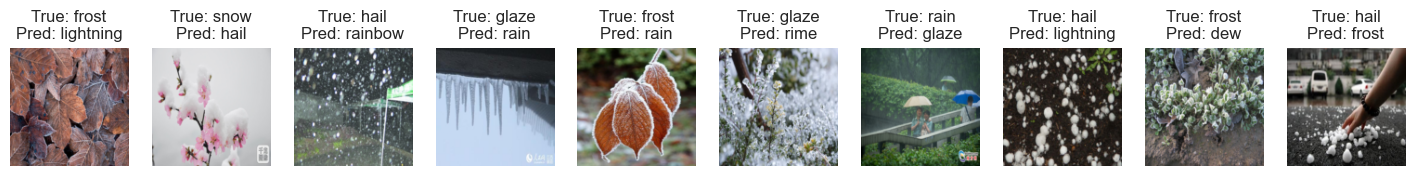

In [23]:
mlp_history = mlp_pipeline.train(criterion, optimizer)

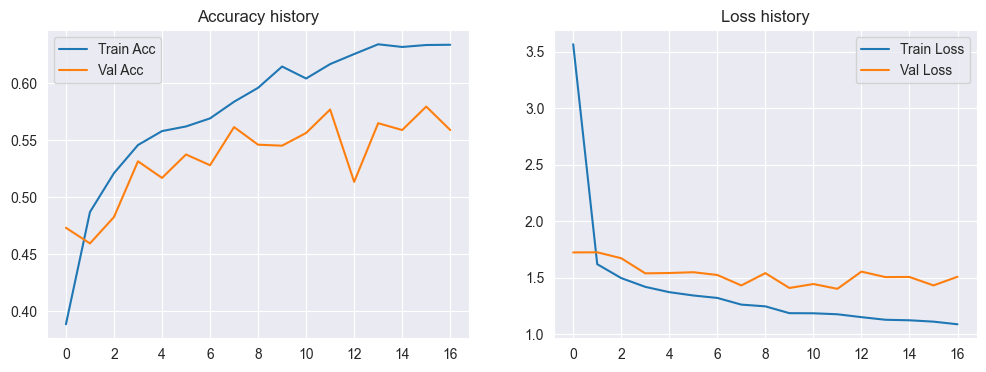

In [24]:
mlp_pipeline.plot_history()

In [25]:
print(f"Точность на тестовой выборке (MLP): {mlp_pipeline.history['test_acc']:.4f}")

Точность на тестовой выборке (MLP): 0.5408


In [26]:
num_classes = len(class_names)
cnn_model = CNN(num_classes=num_classes)

In [27]:
cnn_pipeline = Pipeline(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
    epochs=30,
    patience=5,
    model_name="cnn_weather"
)

In [28]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

Результаты на 5 эпохе:
   Train Loss: 0.8946 | Train Acc: 69.1104%
   Val Loss:   0.8788 | Val Acc:   70.0943%
Результаты на 10 эпохе:
   Train Loss: 0.7139 | Train Acc: 75.2840%
   Val Loss:   0.8189 | Val Acc:   72.4936%
Результаты на 15 эпохе:
   Train Loss: 0.5367 | Train Acc: 81.7149%
   Val Loss:   0.7691 | Val Acc:   73.4362%
Ранняя остановка на 17 эпохе | Best Loss: 0.7444


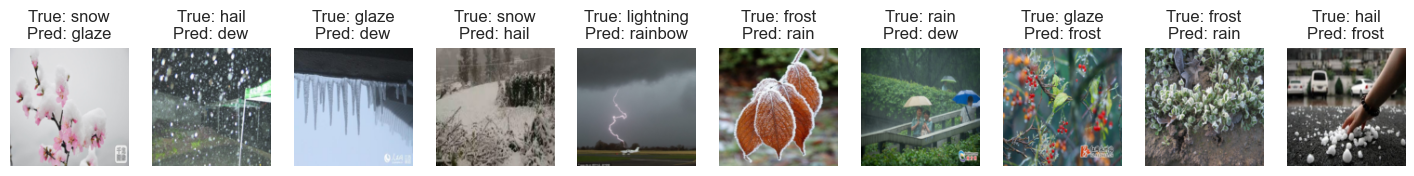

In [29]:
cnn_history = cnn_pipeline.train(criterion, optimizer)

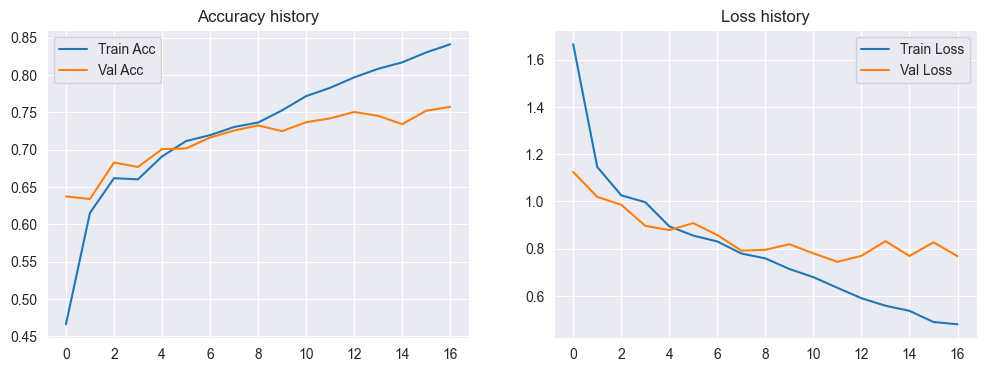

In [30]:
cnn_pipeline.plot_history()

In [31]:
model_mobilenet = timm.create_model(
    'mobilenetv3_small_100.lamb_in1k',
    pretrained=True,
    num_classes=len(class_names)
)
model_mobilenet.to(device)

MobileNetV3(
  (conv_stem): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): Hardswish()
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
        (bn1): BatchNormAct2d(
          16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): ReLU(inplace=True)
          (conv_expand): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (gate): Hardsigmoid()
        )
        (conv_pw): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): B

In [32]:
mobilenet_pipeline = Pipeline(
    model=model_mobilenet,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
    epochs=15,
    model_name="mobilenet_weather"
)

In [33]:
optimizer = torch.optim.AdamW(model_mobilenet.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()

Результаты на 5 эпохе:
   Train Loss: 0.3307 | Train Acc: 89.2819%
   Val Loss:   0.5794 | Val Acc:   82.2622%
Результаты на 10 эпохе:
   Train Loss: 0.1508 | Train Acc: 94.6624%
   Val Loss:   0.6048 | Val Acc:   83.5476%
Результаты на 15 эпохе:
   Train Loss: 0.0811 | Train Acc: 96.9989%
   Val Loss:   0.5805 | Val Acc:   85.6041%


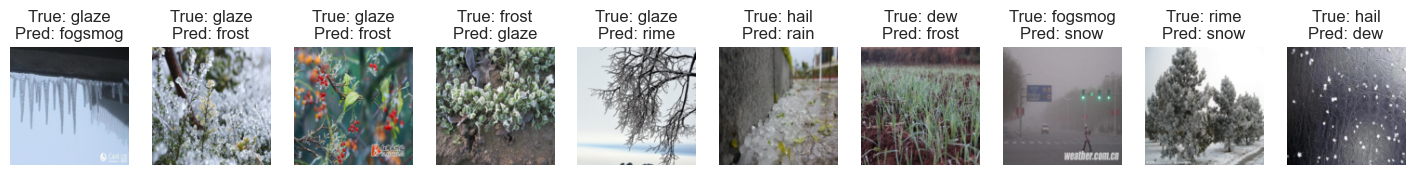

In [34]:
mobilenet_history = mobilenet_pipeline.train(criterion, optimizer)

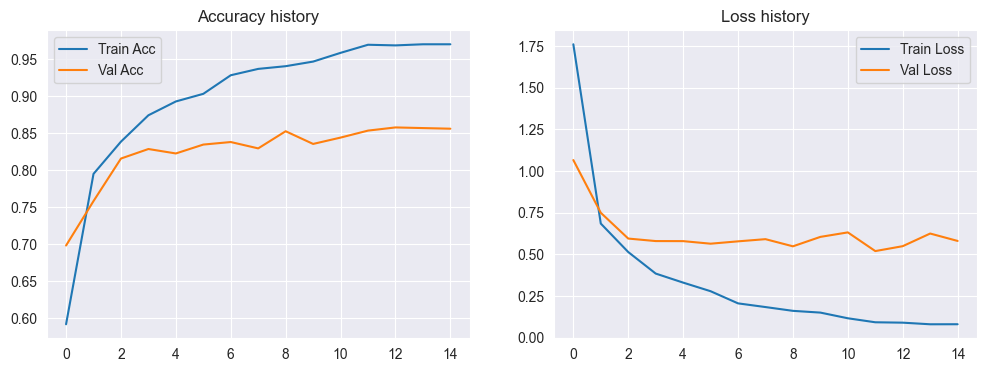

In [35]:
mobilenet_pipeline.plot_history()

In [36]:
model_name = "google/vit-base-patch16-224"

In [37]:
processor = ViTImageProcessor.from_pretrained(model_name)

loading configuration file preprocessor_config.json from cache at /Users/veronika_steklo/.cache/huggingface/hub/models--google--vit-base-patch16-224/snapshots/3f49326eb077187dfe1c2a2bb15fbd74e6ab91e3/preprocessor_config.json
size should be a dictionary on of the following set of keys: ({'width', 'height'}, {'shortest_edge'}, {'longest_edge', 'shortest_edge'}, {'longest_edge'}, {'max_height', 'max_width'}), got 224. Converted to {'height': 224, 'width': 224}.
Image processor ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [38]:
vit_model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=len(class_names),
    id2label={i: c for i, c in enumerate(class_names)},
    label2id={c: i for i, c in enumerate(class_names)},
    ignore_mismatched_sizes=True
)
vit_model.to(device)

loading configuration file config.json from cache at /Users/veronika_steklo/.cache/huggingface/hub/models--google--vit-base-patch16-224/snapshots/3f49326eb077187dfe1c2a2bb15fbd74e6ab91e3/config.json
Model config ViTConfig {
  "architectures": [
    "ViTForImageClassification"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "id2label": {
    "0": "dew",
    "1": "fogsmog",
    "2": "frost",
    "3": "glaze",
    "4": "hail",
    "5": "lightning",
    "6": "rain",
    "7": "rainbow",
    "8": "rime",
    "9": "sandstorm",
    "10": "snow"
  },
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "dew": 0,
    "fogsmog": 1,
    "frost": 2,
    "glaze": 3,
    "hail": 4,
    "lightning": 5,
    "rain": 6,
    "rainbow": 7,
    "rime": 8,
    "sandstorm": 9,
    "snow": 10
  },
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [39]:
mu, std = processor.image_mean, processor.image_std
size = processor.size['height']

vit_transforms = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mu, std=std)
])

In [40]:
vit_train_data = ApplyTransform(torch.utils.data.Subset(full_dataset, train_idx), transform=vit_transforms)
vit_val_data = ApplyTransform(torch.utils.data.Subset(full_dataset, val_idx), transform=vit_transforms)
vit_test_data = ApplyTransform(torch.utils.data.Subset(full_dataset, test_idx), transform=vit_transforms)

In [41]:
vit_train_loader = DataLoader(vit_train_data, batch_size=32, shuffle=True)
vit_val_loader = DataLoader(vit_val_data, batch_size=32, shuffle=False)
vit_test_loader = DataLoader(vit_test_data, batch_size=32, shuffle=False)

In [42]:
class ViTWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x).logits


wrapped_vit = ViTWrapper(vit_model)

In [43]:
vit_pipeline = Pipeline(
    model=wrapped_vit,
    train_loader=vit_train_loader,
    val_loader=vit_val_loader,
    test_loader=vit_test_loader,
    class_names=class_names,
    device=device,
    epochs=10,
    patience=3,
    model_name="vit_weather"
)

In [44]:
optimizer = torch.optim.AdamW(vit_model.parameters(), lr=2e-5)
criterion = torch.nn.CrossEntropyLoss()

Результаты на 5 эпохе:
   Train Loss: 0.0152 | Train Acc: 99.9143%
   Val Loss:   0.2040 | Val Acc:   93.3162%
Ранняя остановка на 7 эпохе | Best Loss: 0.1864


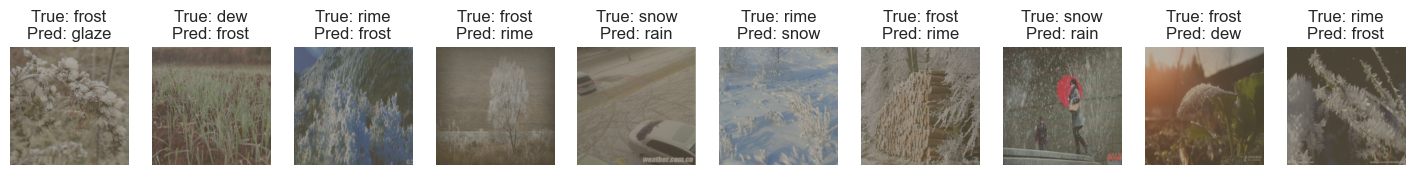

In [45]:
vit_history = vit_pipeline.train(criterion, optimizer)

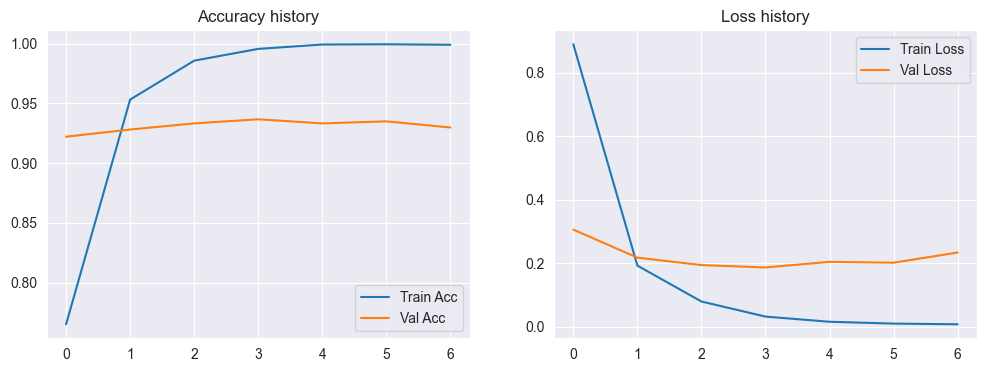

In [46]:
vit_pipeline.plot_history()

In [50]:
from torch import nn
from torchvision import models


def get_resnet_model(num_classes, model_name='resnet18'):
    if model_name == 'resnet18':
        model = models.resnet18(weights='IMAGENET1K_V1')
    elif model_name == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1')
    else:
        return timm.create_model(model_name, pretrained=False, num_classes=num_classes)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

In [51]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [54]:
num_classes = len(class_names)
resnet_model = get_resnet_model(num_classes, model_name='resnet50')
resnet_model = resnet_model.to(device)

In [55]:
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [57]:
resnet_pipeline = Pipeline(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
    epochs=20,
    patience=5,
    model_name="resnet50_weather"
)

Результаты на 5 эпохе:
   Train Loss: 0.1153 | Train Acc: 96.3130%
   Val Loss:   0.3741 | Val Acc:   88.9460%
Ранняя остановка на 8 эпохе | Best Loss: 0.3397


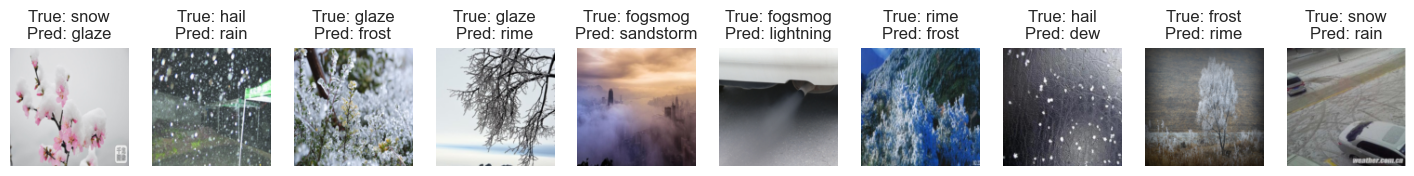

In [58]:
resnet_history = resnet_pipeline.train(criterion, optimizer)

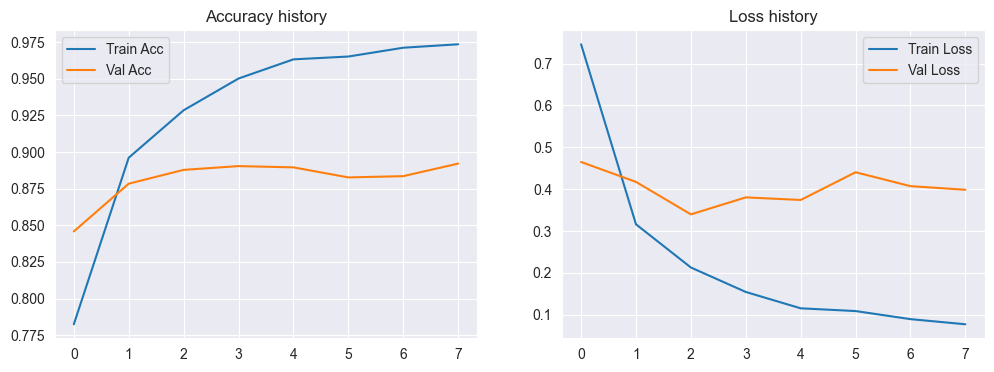

In [59]:
resnet_pipeline.plot_history()